In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from config import (
    N, p0, Lambda, lam, T, y_intervals,
    t_net_filtering, pi_uniform, pi_uniform, M_net,
    ht, delta, F, G, get_obs, exp_id, delta1, delta2
)
from SMJP import (
    sparse_mc, get_y_uniform, 
    make_discretized_xi, make_discretized_eta
)
from utils import load_saved_path, save_path
from filter import Filter
from plots import plot_theta, plot_y, plot_obs, plot_theta_background

print(exp_id)

diffusion_approx_low_freq


In [3]:
load_path = False

In [4]:
if load_path:
    theta, y, t, theta_est, y_est, observations = load_saved_path(exp_id)
else:
    theta, y, t = sparse_mc(p0, Lambda, lam, T, get_y_uniform, y_intervals)
    observations = get_obs(t_net_filtering, theta, y, t)#.squeeze(axis=-1)

ValueError: too many values to unpack (expected 1)

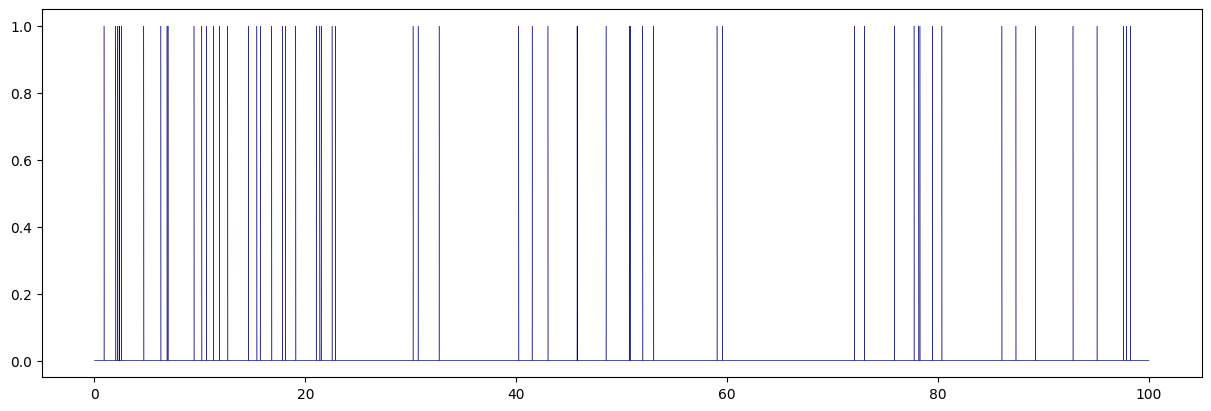

In [6]:
fig, ax = plt.subplots(figsize=(12, 4), layout='constrained')

plot_freq = 1

line, = ax.plot(
    t_net_filtering[1::plot_freq],
    observations[::plot_freq, 0],
    lw=0.3,
    color='navy',
    label='$\\Delta \\xi$'
)

theta_states = plot_theta_background(
    ax, theta, t, 
    [f'$\\theta = e_{i}$' for i in range(1, N+1)], 
    ['blue', 'green', 'red'], 
    T, 
    alpha=0.3
)


ax.set_xlim(t_net_filtering[0], t_net_filtering[-1])

ax.set_xticks(
    ticks=list(range(0, 101, 20)), 
    labels=['0', '20', '40', '60', '80', '$t$'],
    fontsize=12,
)

ax.tick_params(labelsize=16)

fig.legend(
    handles=theta_states + [line],
    loc='outside lower center',
    ncols=len(theta_states) + 1,
    fontsize=16,
    frameon=False
)

plt.show()

In [6]:
if not load_path:
    filter = Filter(
        p0[:, np.newaxis] * pi_uniform, 
        pi_uniform, M_net, F, G,
        N, Lambda, ht, delta
    )

    est = filter.estimate()
    theta_est = [est[0]]
    y_est = [est[1]]

    for i, obs in enumerate(tqdm(observations[:200]), start=1):
        #obs = np.array([obs])
        filter.update(obs.squeeze())
        est = filter.estimate()
        if np.any(np.isnan(est[0])) or np.any(np.isnan(est[1])):
            print(f'nan on {i}-th iter')
            break
        theta_est.append(est[0])
        y_est.append(est[1])
    
    theta_est = np.array(theta_est)
    y_est = np.array(y_est)

  0%|          | 0/200 [00:00<?, ?it/s]

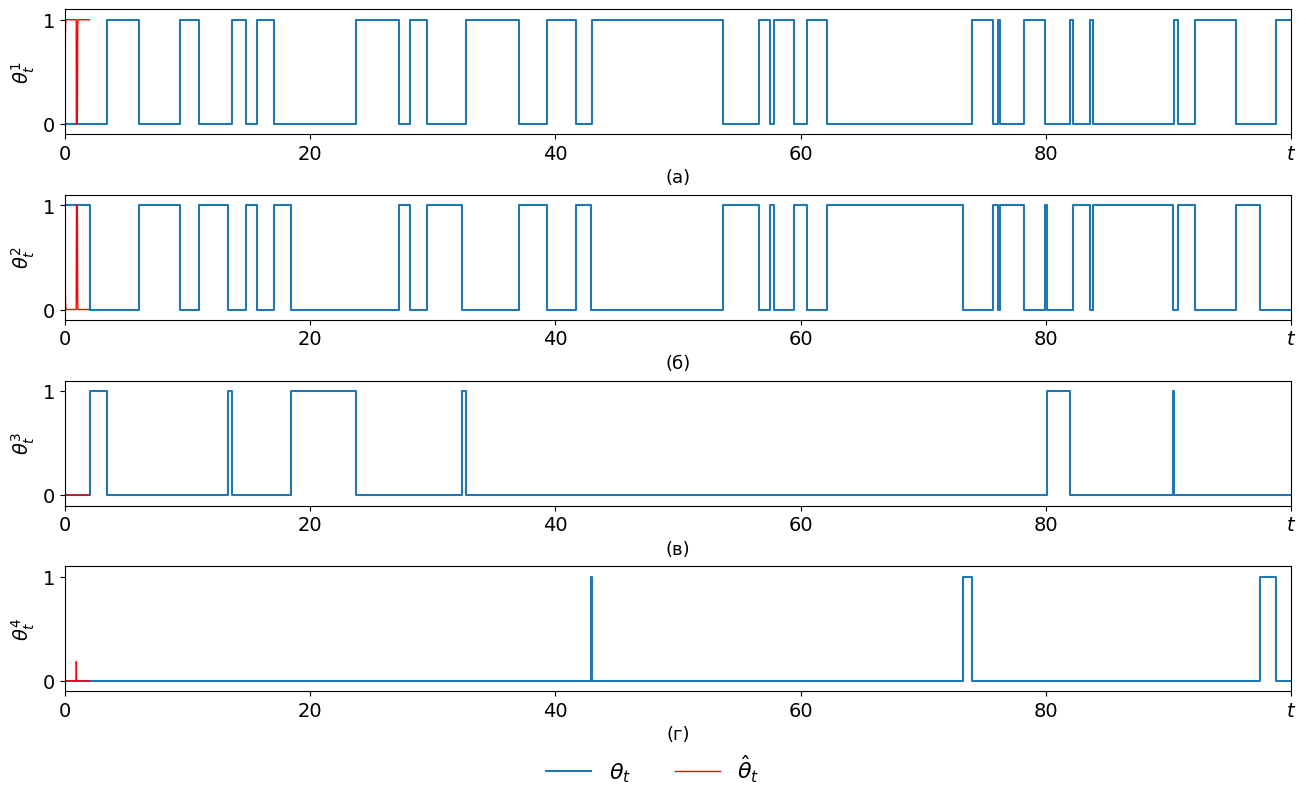

In [7]:
fig, ax = plot_theta(theta, t, theta_est)


plt.show()

In [8]:
if not load_path:
    save_path(exp_id, theta, y, t, theta_est, y_est, observations)

In [9]:
delta

np.float64(0.0004004004004004004)

In [10]:
y_intervals[0]

array([[0.1 , 0.25],
       [0.25, 0.4 ],
       [0.4 , 0.5 ]])

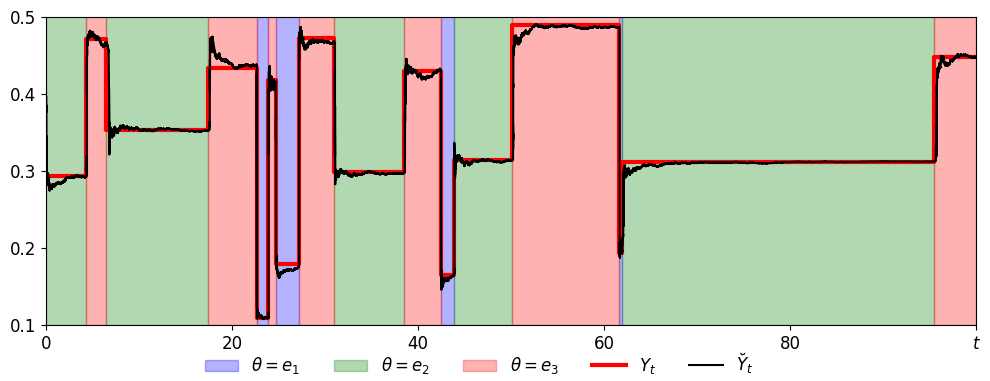

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
y_tmp = y[:, 0]
state, = ax.step(
    [0] + list(t),
    [y_tmp[0]] + list(y_tmp),
    where='pre', lw=3, color='red',
    label='$Y_t$'
)

theta_lines = plot_theta_background(
    ax, theta, t, 
    [f'$\\theta = e_{i}$' for i in range(1, N+1)], 
    ['blue', 'green', 'red'], 
    T, alpha=0.3
)

estimate, = ax.plot(t_net_filtering, y_est[:, 0], color='black', label='$\\breve{Y}_t$')


#ax.axhline(y_intervals[0][0, 1])
#ax.axhline(y_intervals[0][1, 1])

ax.set_xlim(t_net_filtering[0], t_net_filtering[-1])
ax.set_ylim(0.1, 0.5)

ax.set_xticks(
    ticks=list(range(0, 101, 20)), 
    labels=['0', '20', '40', '60', '80', '$t$'],
    fontsize=12,
)

ax.set_yticks(
    ticks=[0.1, 0.2, 0.3, 0.4, 0.5],
    labels=[str(x) for x in [0.1, 0.2, 0.3, 0.4, 0.5]],
    fontsize=12
)

fig.legend(
    handles=theta_lines + [state, estimate],
    #labels=[f'$\\theta = e_{i}$' for i in range(1, N+1, 1)],
    ncols=5,
    fontsize=12,
    loc=(0.2, -0.005),
    frameon=False
)

plt.show()

In [12]:
# with open('saved_path/theta_est.pkl', 'wb') as f:
#     pickle.dump(theta_est, f)
# with open('saved_path/y_est.pkl', 'wb') as f:
#     pickle.dump(y_est, f)
# with open('saved_path/theta.pkl', 'wb') as f:
#     pickle.dump(theta, f)
# with open('saved_path/y.pkl', 'wb') as f:
#     pickle.dump(y, f)
# with open('saved_path/t.pkl', 'wb') as f:
#     pickle.dump(t, f)